# Walmart

## Data Loading, Preprocessing and Cleaning

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Walmart dataset
df0 = pd.read_csv('walmart.csv')

# Drop unnecessary columns (User_ID, Product_ID)
df0.drop(columns=['User_ID', 'Product_ID'], inplace=True)

# Check for missing values
print("\nMissing values per column:")
print(df0.isnull().sum())




Missing values per column:
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64


## EDA

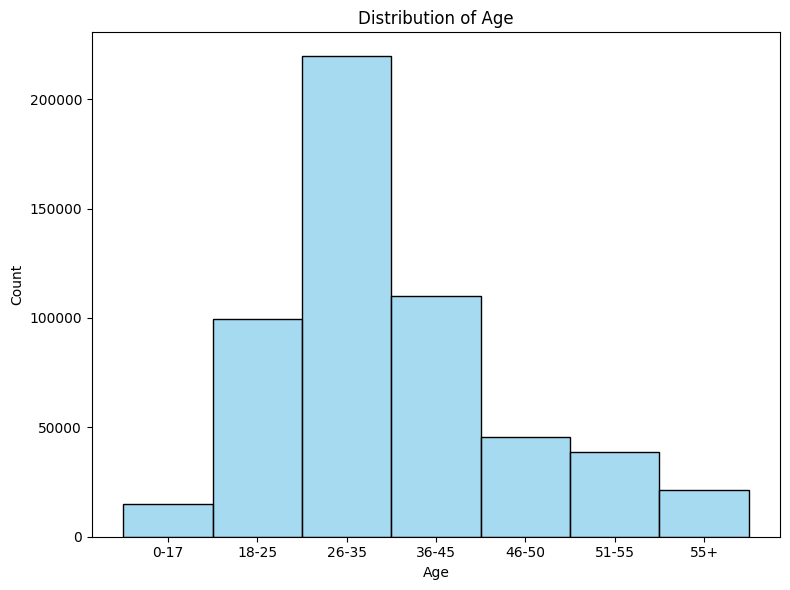

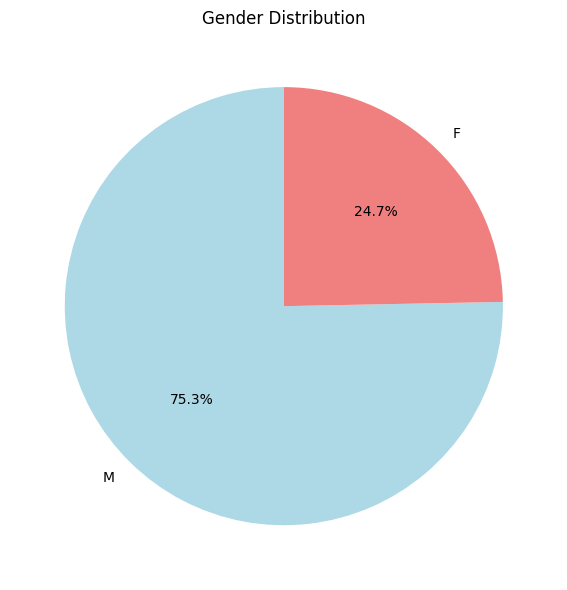

<ipython-input-2-d424fd91b98e>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df0, x='City_Category', palette='Set2')


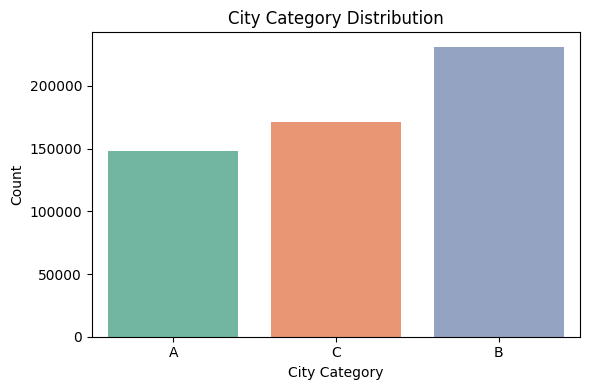

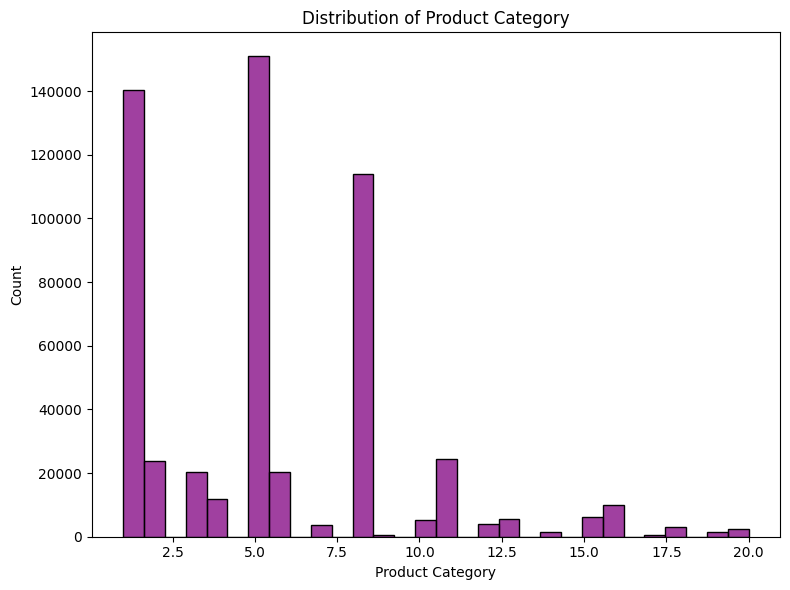

In [2]:
# Visualizations for distribution

# Set the 'Age' column as an ordered categorical variable
age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
df0['Age'] = pd.Categorical(df0['Age'], categories=age_order, ordered=True)

# Plot Age group Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df0['Age'], kde=False, bins=len(age_order), color='skyblue')
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Pie chart for Gender Distribution
gender_counts = df0['Gender'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()

# Countplot for City_Category
plt.figure(figsize=(6, 4))
sns.countplot(data=df0, x='City_Category', palette='Set2')
plt.title("City Category Distribution")
plt.xlabel("City Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Distribution of Product_Category
plt.figure(figsize=(8, 6))
sns.histplot(df0['Product_Category'], kde=False, bins=30, color='purple')
plt.title("Distribution of Product Category")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



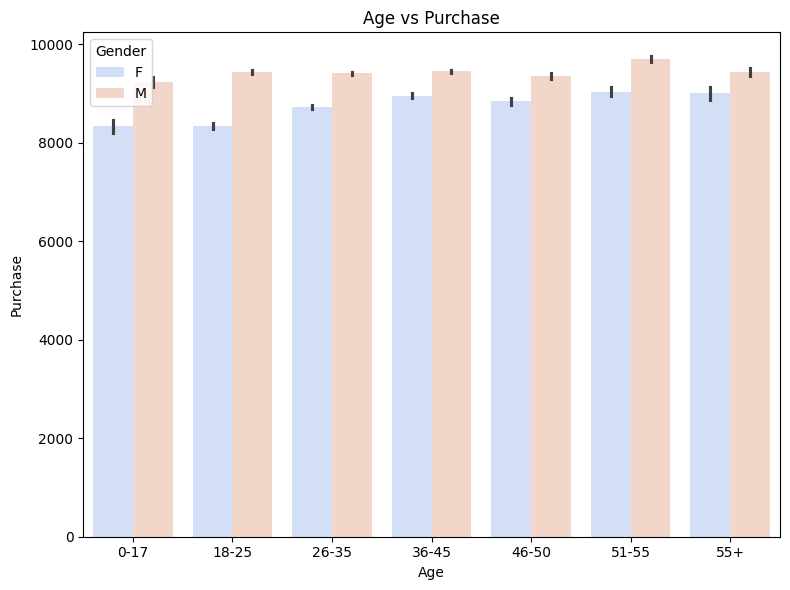

<ipython-input-3-e8d939aa0d19>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df0, x='City_Category', y='Purchase', palette='Set2')


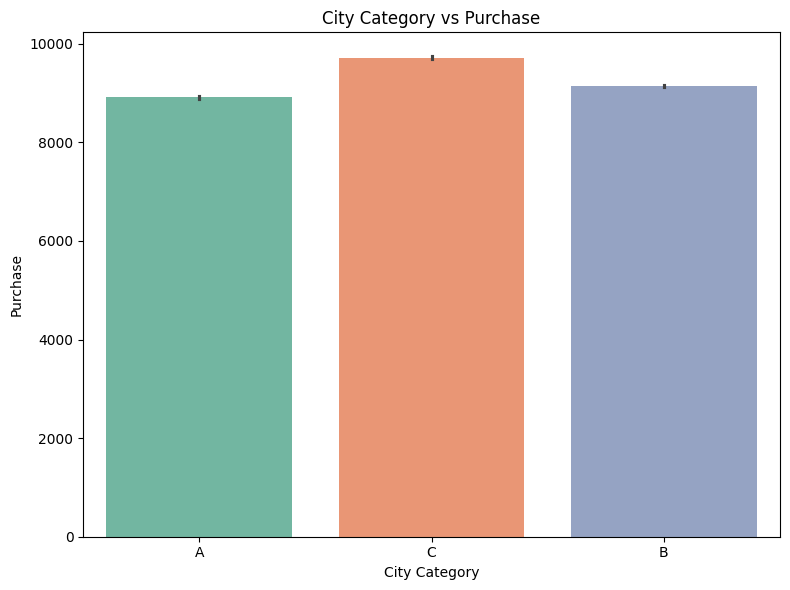

<ipython-input-3-e8d939aa0d19>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df0, x='Product_Category', y='Purchase', palette='coolwarm')


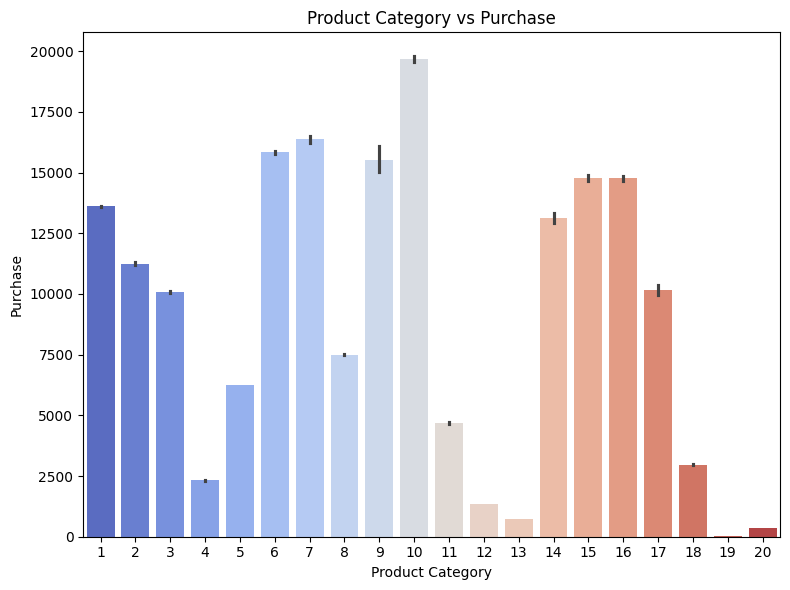

<ipython-input-3-e8d939aa0d19>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df0, x='Marital_Status', y='Purchase', palette='coolwarm')


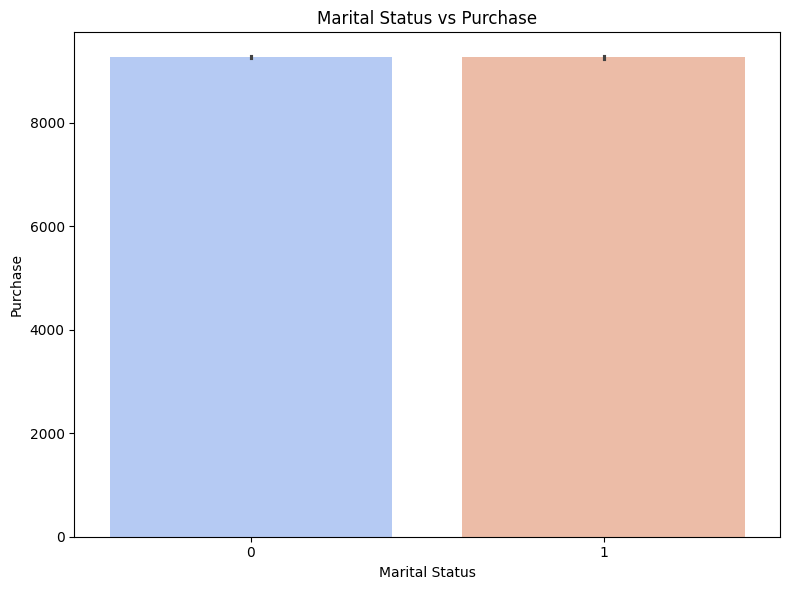

<ipython-input-3-e8d939aa0d19>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df0, x='Gender', y='Purchase', palette='coolwarm')


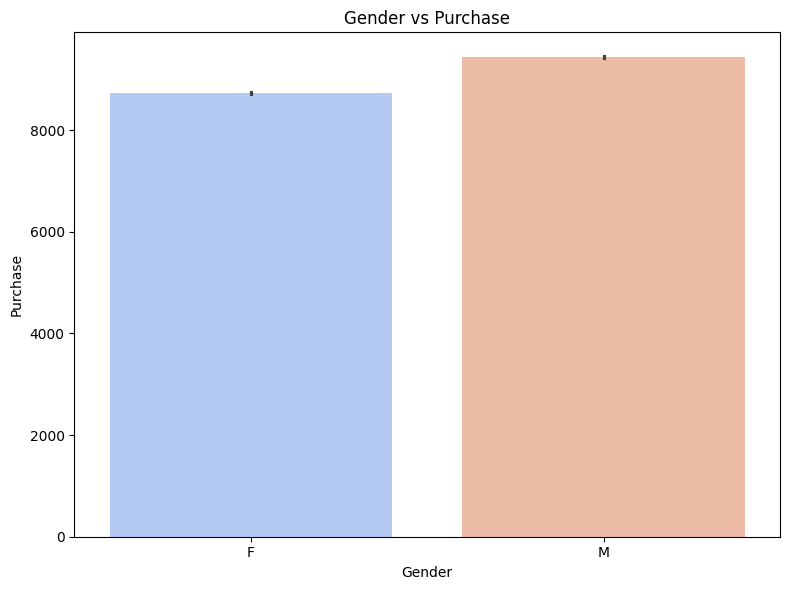

In [3]:
# Age vs Purchase (scatter plot)
plt.figure(figsize=(8, 6))
sns.barplot(data=df0, x='Age', y='Purchase', hue='Gender', palette='coolwarm', alpha=0.6)
plt.title("Age vs Purchase")
plt.xlabel("Age")
plt.ylabel("Purchase")
plt.tight_layout()
plt.show()

# City Category vs Purchase (box plot)
plt.figure(figsize=(8, 6))
sns.barplot(data=df0, x='City_Category', y='Purchase', palette='Set2')
plt.title('City Category vs Purchase')
plt.xlabel('City Category')
plt.ylabel('Purchase')
plt.tight_layout()
plt.show()

# Product Category vs Purchase (Boxplot)
plt.figure(figsize=(8, 6))
sns.barplot(data=df0, x='Product_Category', y='Purchase', palette='coolwarm')
plt.title("Product Category vs Purchase")
plt.xlabel("Product Category")
plt.ylabel("Purchase")
plt.tight_layout()
plt.show()

# Marital Status vs Purchase (Boxplot)
plt.figure(figsize=(8, 6))
sns.barplot(data=df0, x='Marital_Status', y='Purchase', palette='coolwarm')
plt.title("Marital Status vs Purchase")
plt.xlabel("Marital Status")
plt.ylabel("Purchase")
plt.tight_layout()
plt.show()

# Gender vs Purchase (Boxplot)
plt.figure(figsize=(8, 6))
sns.barplot(data=df0, x='Gender', y='Purchase', palette='coolwarm')
plt.title("Gender vs Purchase")
plt.xlabel("Gender")
plt.ylabel("Purchase")
plt.tight_layout()
plt.show()


In [4]:
# Encode categorical features

# Encoding 'Gender' column (M=1, F=0)
df0['Gender'] = df0['Gender'].map({'M': 1, 'F': 0})

# Encoding 'Age' as categorical with unique encoding for each age value
df0['Age'] = df0['Age'].map({'0-17':0,'18-25':1,'26-35':2,'36-45':3, '46-50':4,'51-55':5,'55+':6})

# Encoding 'City_Category' (A=0, B=1, C=2)
df0['City_Category'] = df0['City_Category'].map({'A': 0, 'B': 1, 'C': 2})

# Encoding 'Stay_In_Current_City_Years' (categorical-like, treated as integer)
df0['Stay_In_Current_City_Years'] = df0['Stay_In_Current_City_Years'].map({'0': 0, '1': 1, '2': 2, '3': 3, '4+': 4})

# Encoding 'Marital_Status' (0=single, 1=married)
df0['Marital_Status'] = df0['Marital_Status'].map({0: 0, 1: 1})

# Encoding 'Product_Category' as an integer for analysis purposes
df0['Product_Category'] = df0['Product_Category'].astype('category').cat.codes

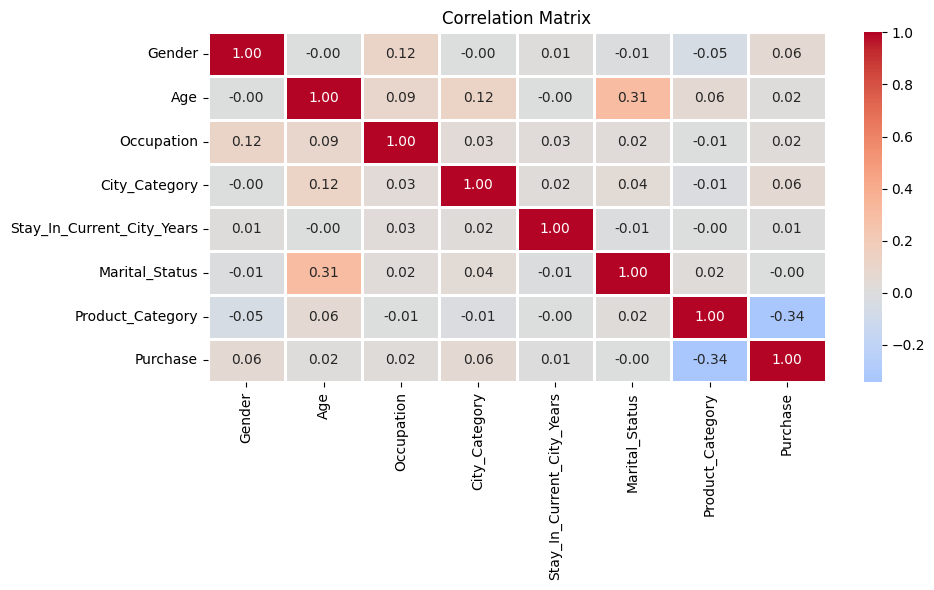

In [5]:
# Correlation matrix

# Compute the correlation matrix
corr = df0.corr()

# Plot the heatmap of correlations
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Synthetic Analysis

## Data Loading, Preprocessing and Cleaning

In [6]:
# Read the data
df = pd.read_csv("new_retail_data.csv")

# Columns to drop based on relevance to analysis
columns_to_drop = ['Transaction_ID', 'Customer_ID', 'Name', 'Email', 'Phone', 'Address', 'State', 'Zipcode', 'City', 'Year', 'Month', 'Time', 'Amount', 'Feedback', 'Shipping_Method','Payment_Method', 'Order_Status', 'Ratings', 'products']

# Drop the specified columns from the dataframe
df.drop(columns=columns_to_drop, inplace=True)

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())




Missing values per column:
Country             271
Age                 173
Gender              317
Income              290
Customer_Segment    215
Date                359
Total_Purchases     361
Total_Amount        350
Product_Category    283
Product_Brand       281
Product_Type          0
dtype: int64


In [7]:
# List of columns with missing values
columns_with_missing_values = [
    'Country', 'Age', 'Gender', 'Income', 'Customer_Segment', 'Date',
    'Total_Purchases', 'Total_Amount',
    'Product_Category', 'Product_Brand', 'Product_Type'
]

# Drop rows where any of these columns have missing values
df_cleaned = df.dropna(subset=columns_with_missing_values)

# Check the number of rows remaining
print(f"Remaining rows after dropping missing values: {df_cleaned.shape[0]}")

# Check for missing values in the remaining dataset
print("\nMissing values in the cleaned dataset:")
print(df_cleaned.isnull().sum())


Remaining rows after dropping missing values: 299114

Missing values in the cleaned dataset:
Country             0
Age                 0
Gender              0
Income              0
Customer_Segment    0
Date                0
Total_Purchases     0
Total_Amount        0
Product_Category    0
Product_Brand       0
Product_Type        0
dtype: int64


## EDA

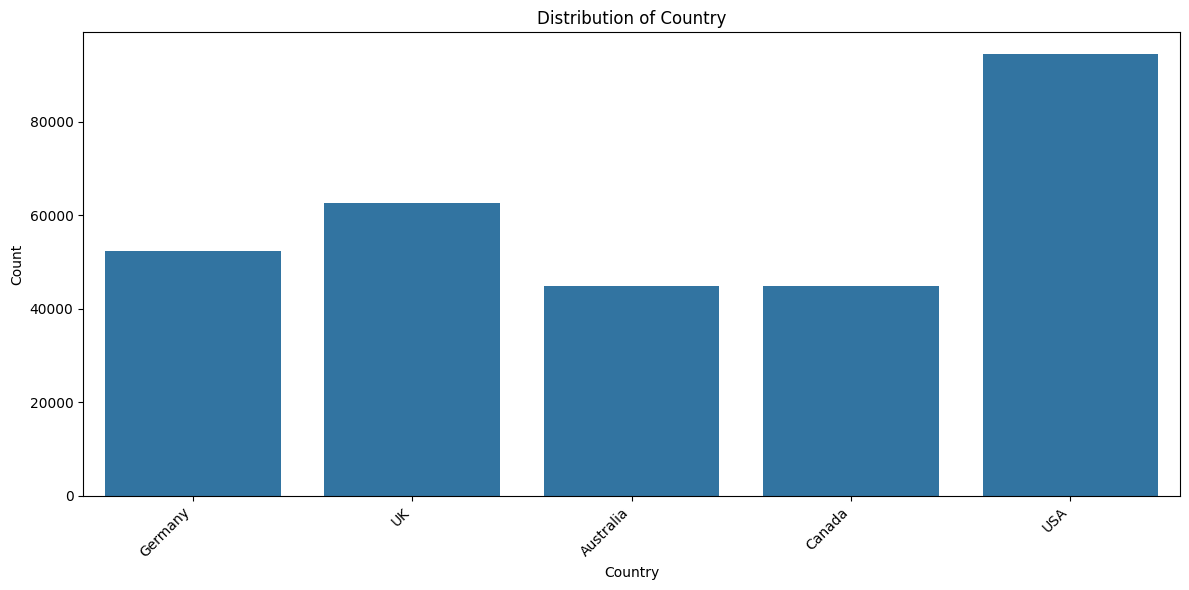

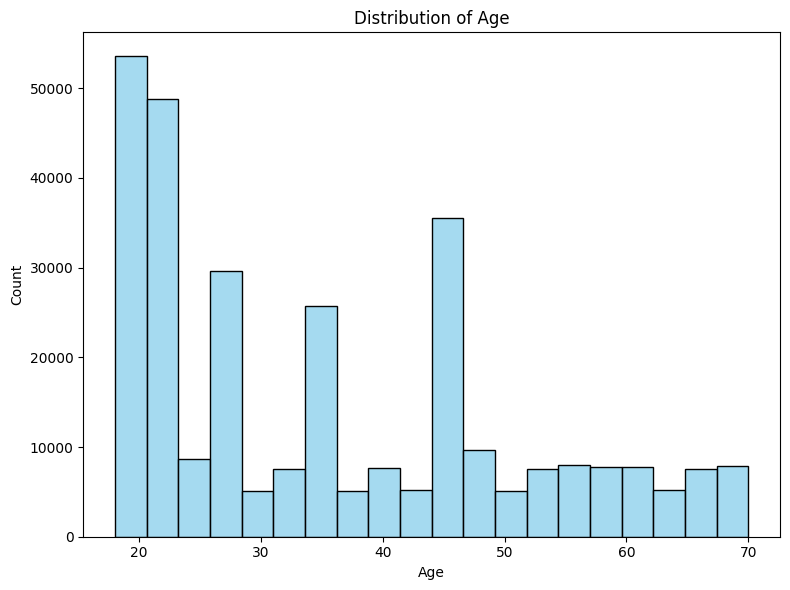

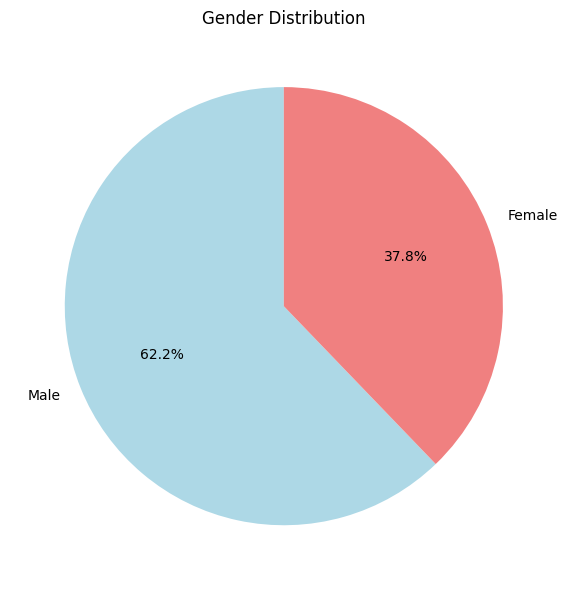

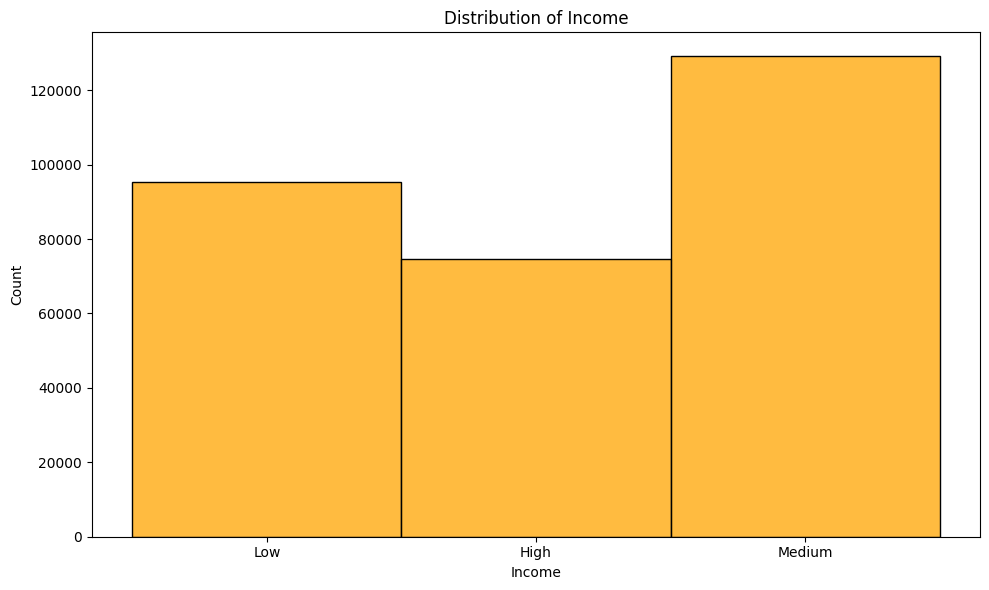

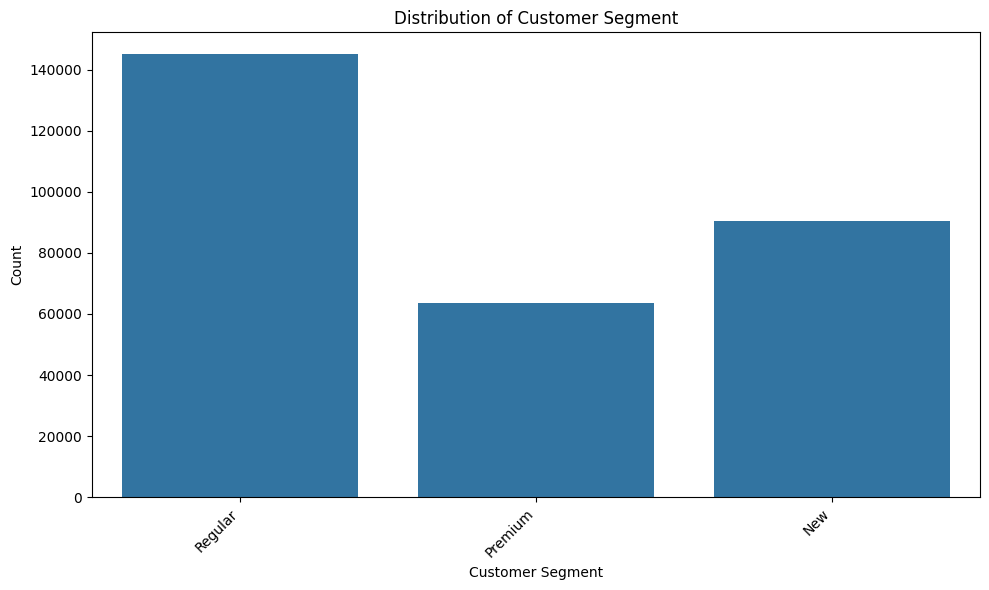

<ipython-input-8-612ffbd44f50>:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])


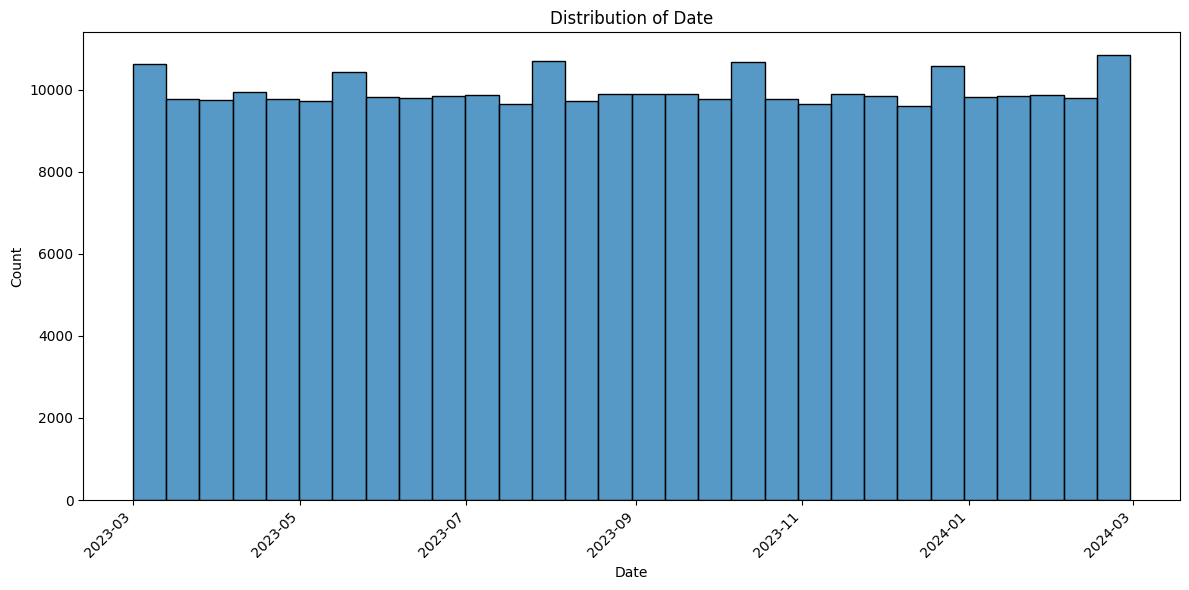

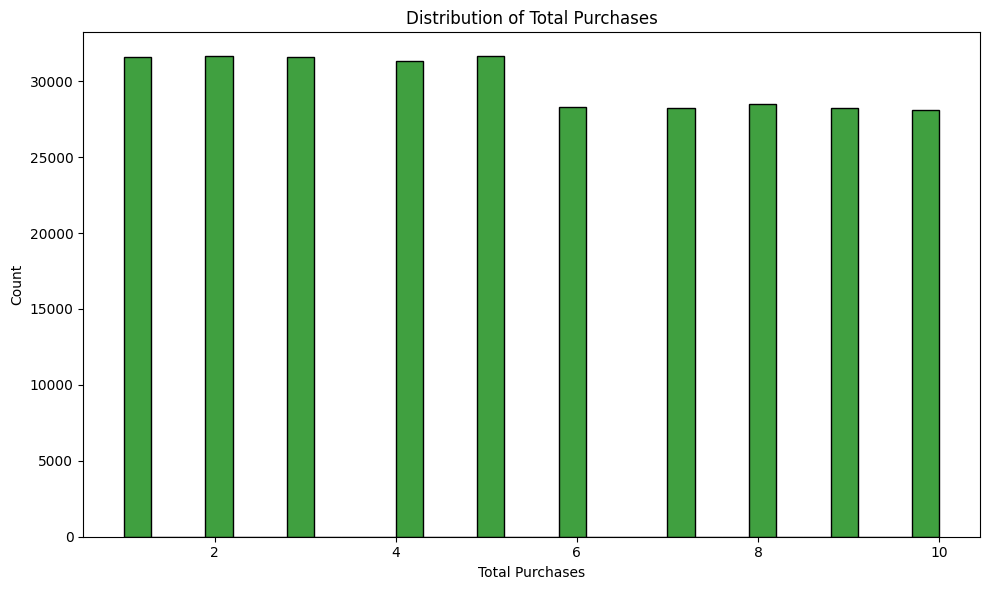

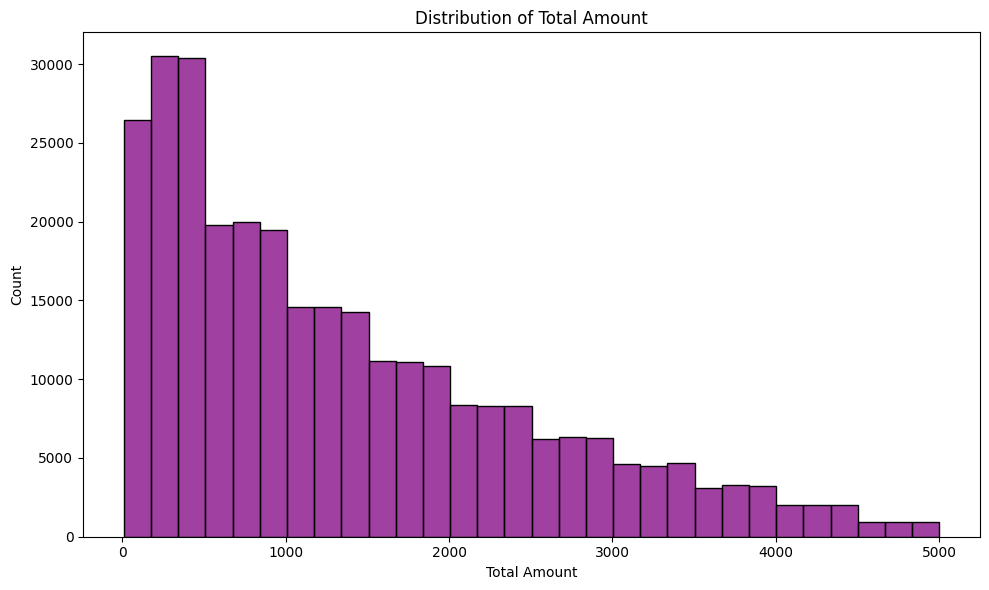

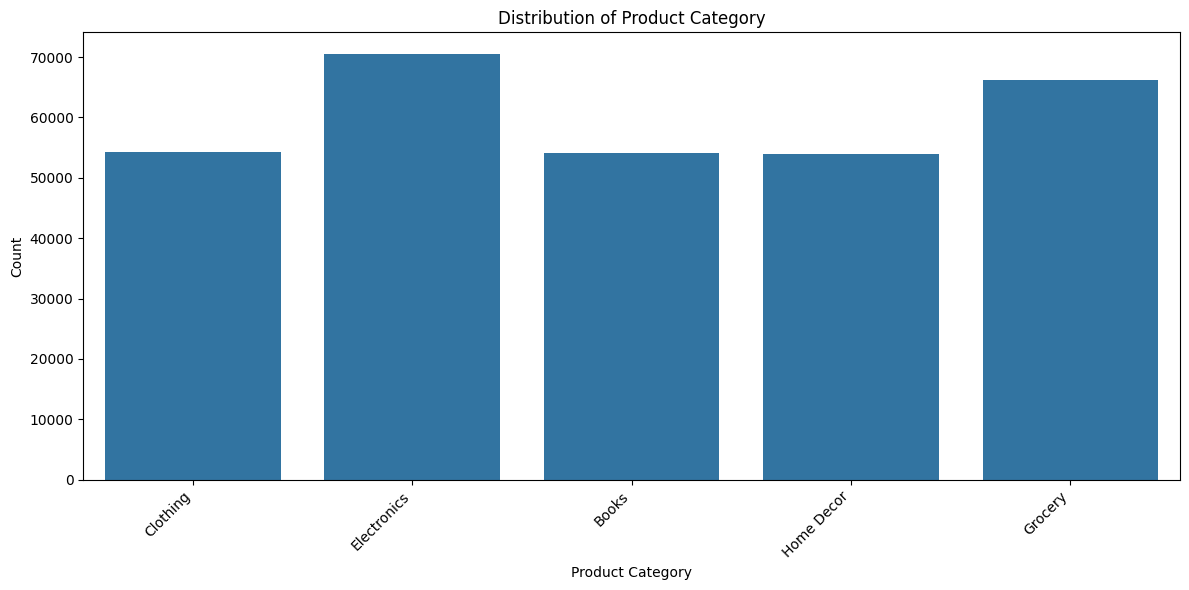

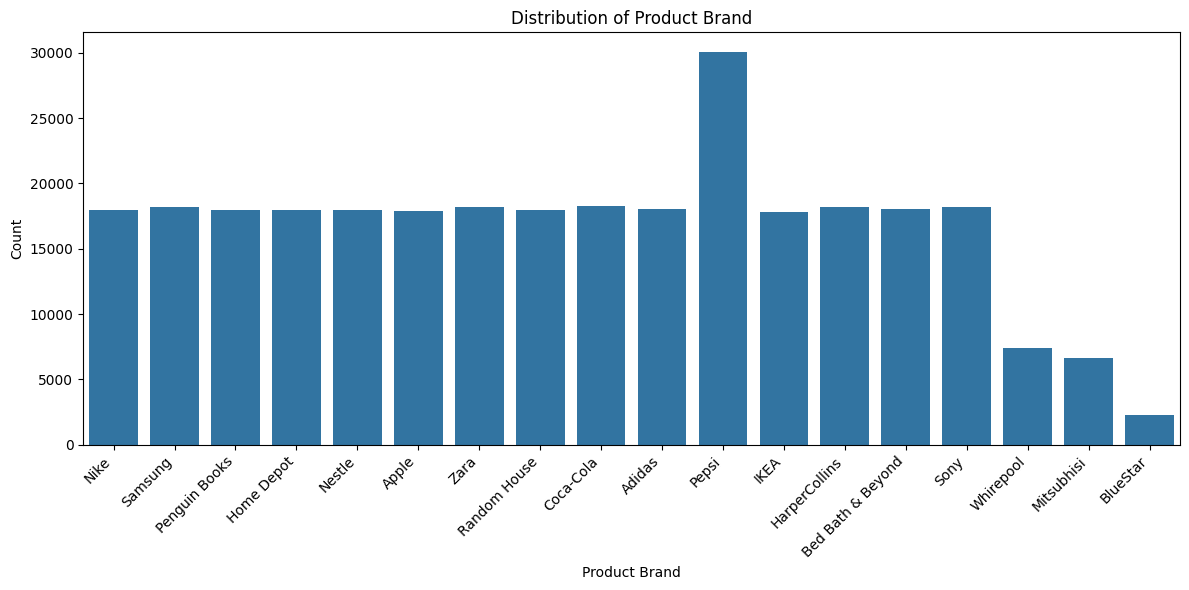

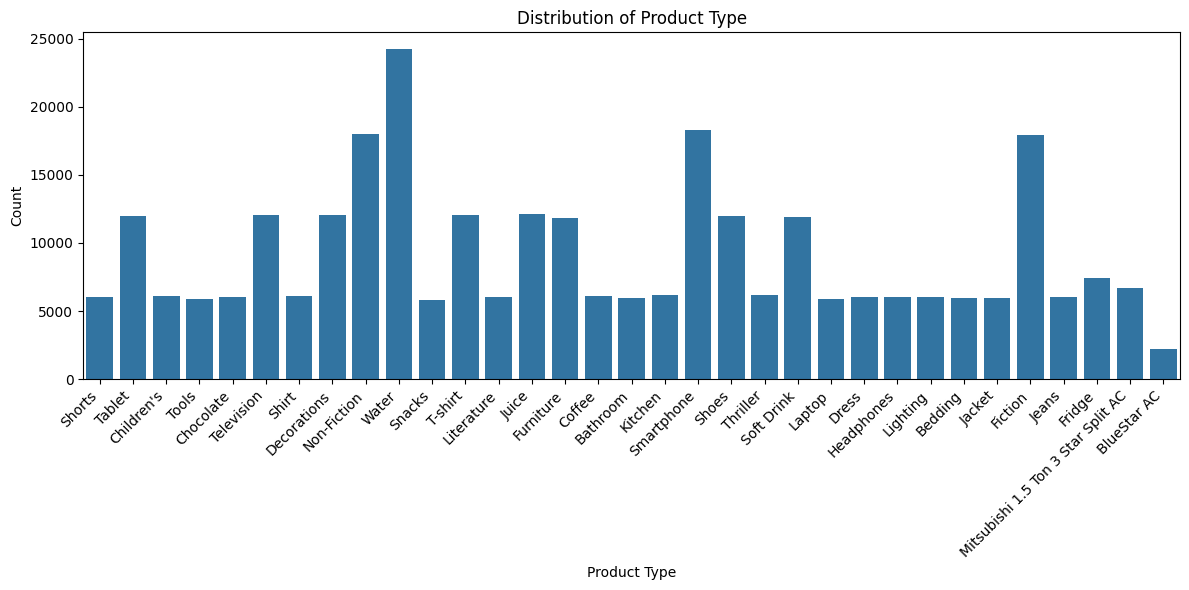

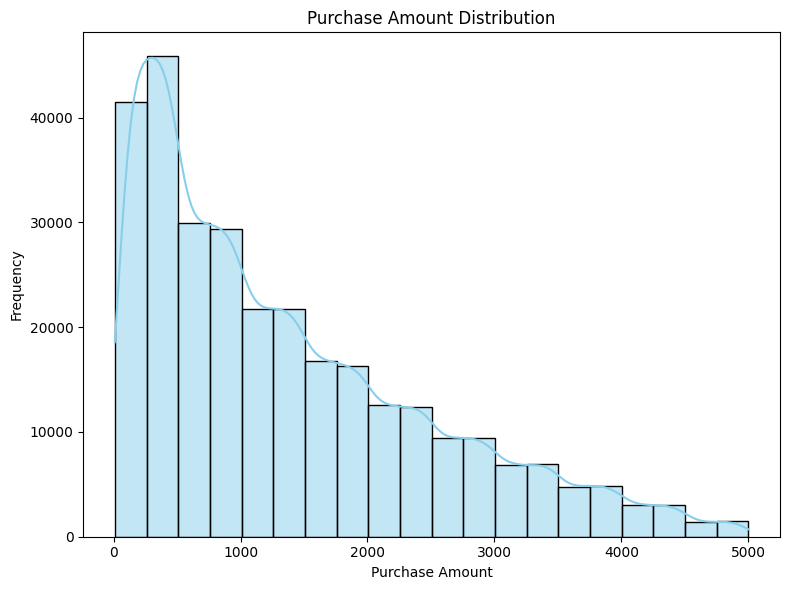

In [8]:

# Distribution of Country
plt.figure(figsize=(12, 6))
sns.countplot(data=df_cleaned, x='Country')
plt.title("Distribution of Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Distribution of Age
plt.figure(figsize=(8, 6))
sns.histplot(df_cleaned['Age'], kde=False, bins=20, color='skyblue')
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Pie chart for Gender Distribution
gender_counts = df_cleaned['Gender'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()


# Distribution of Income
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Income'], kde=False, bins=30, color='orange')
plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Distribution of Customer_Segment
plt.figure(figsize=(10, 6))
sns.countplot(data=df_cleaned, x='Customer_Segment')
plt.title("Distribution of Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Distribution of Date
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])
plt.figure(figsize=(12, 6))
sns.histplot(df_cleaned['Date'], kde=False, bins=30)
plt.title("Distribution of Date")
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Distribution of Total_Purchases
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Total_Purchases'], kde=False, bins=30, color='green')
plt.title("Distribution of Total Purchases")
plt.xlabel("Total Purchases")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Distribution of Total_Amount
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Total_Amount'], kde=False, bins=30, color='purple')
plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Distribution of Product_Category
plt.figure(figsize=(12, 6))
sns.countplot(data=df_cleaned, x='Product_Category')
plt.title("Distribution of Product Category")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Distribution of Product_Brand
plt.figure(figsize=(12, 6))
sns.countplot(data=df_cleaned, x='Product_Brand')
plt.title("Distribution of Product Brand")
plt.xlabel("Product Brand")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Distribution of Product_Type
plt.figure(figsize=(12,6))
sns.countplot(data=df_cleaned, x='Product_Type')
plt.title("Distribution of Product Type")
plt.xlabel("Product Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Distribution of purchase amount
plt.figure(figsize=(8, 6))
sns.histplot(df_cleaned['Total_Amount'], kde=True, bins=20, color='skyblue')
plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



<ipython-input-9-64d8bab1b7be>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Age_Group'] = pd.cut(df_cleaned['Age'], bins=age_bins, labels=age_labels)


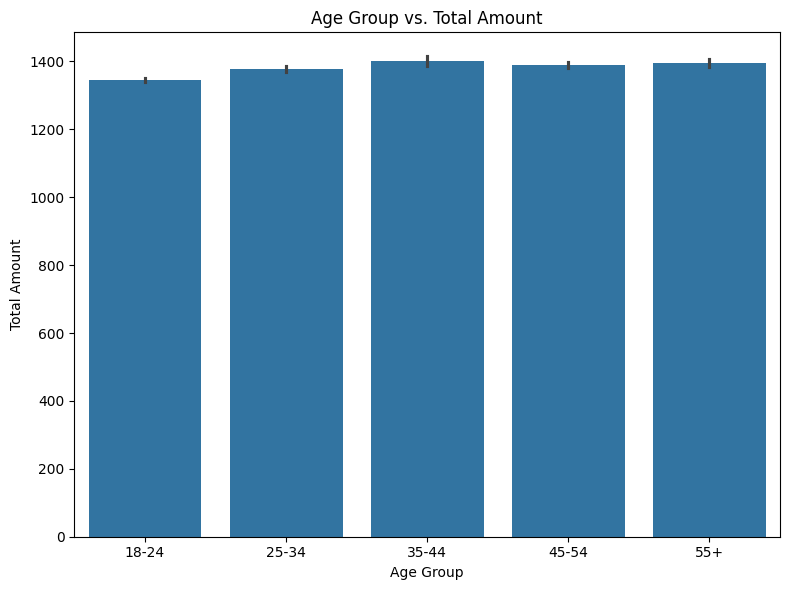

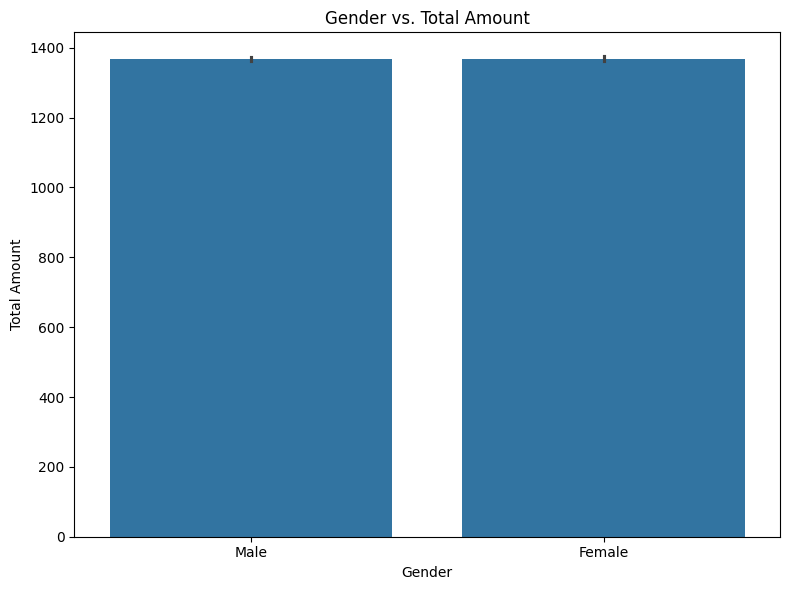

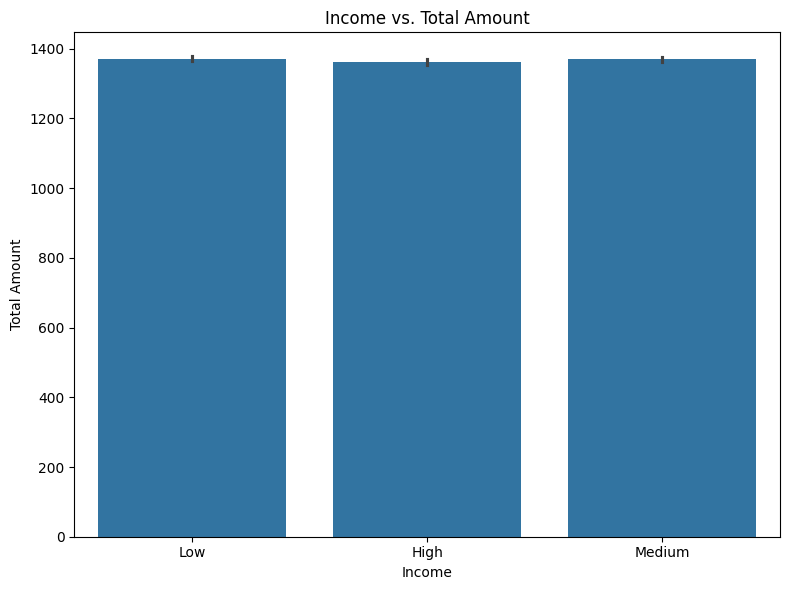

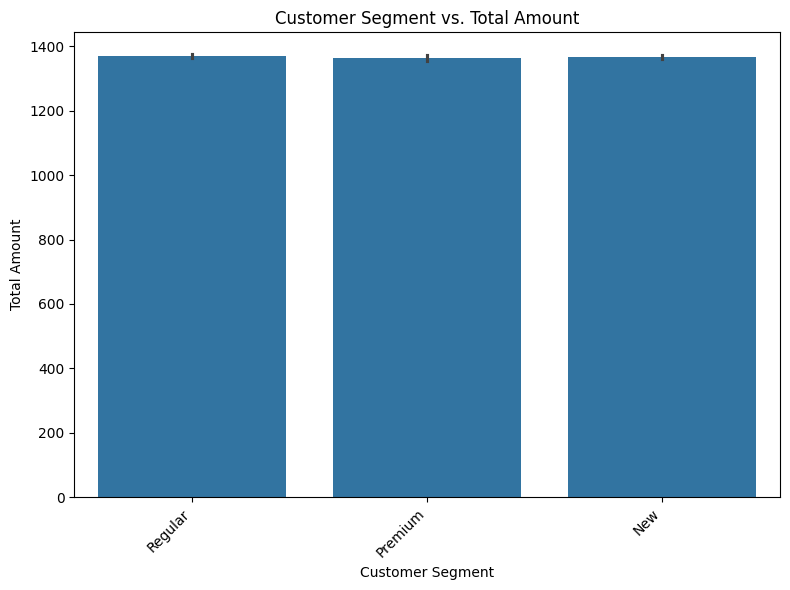

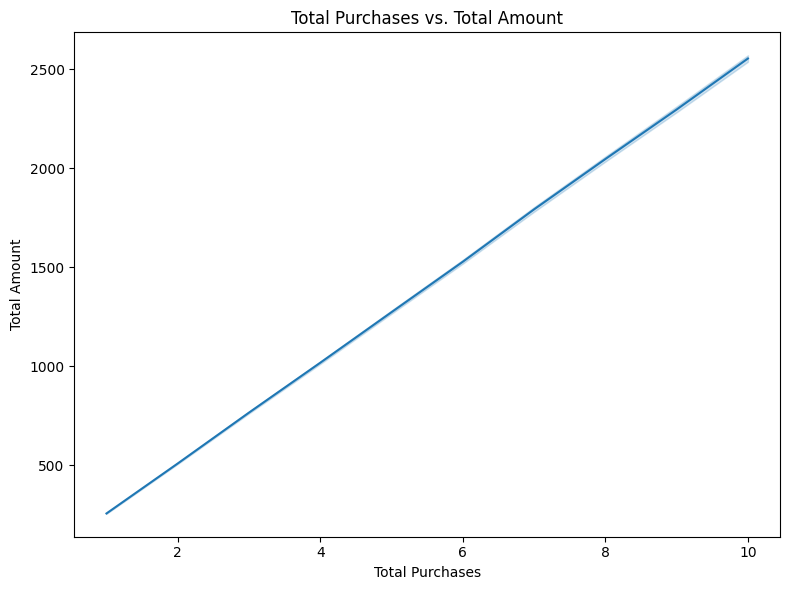

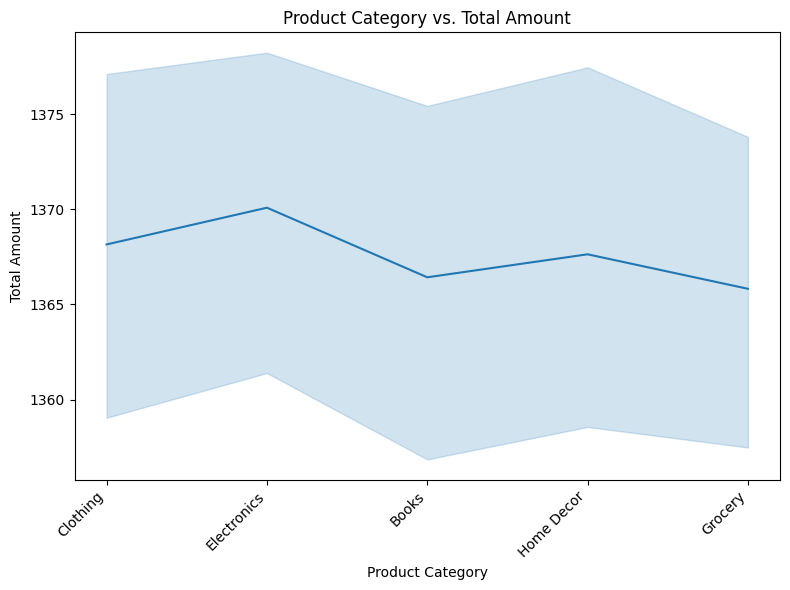

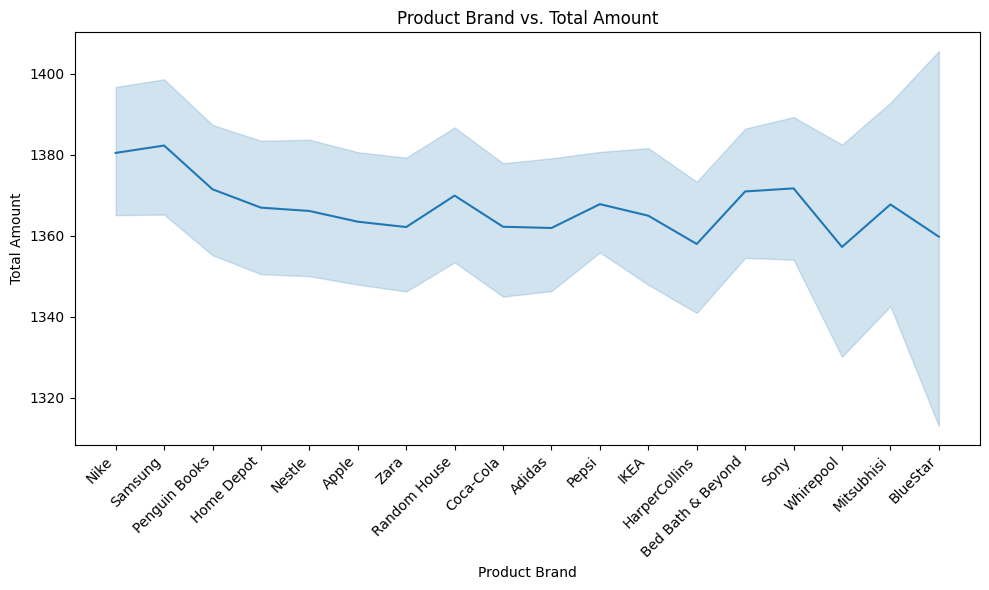

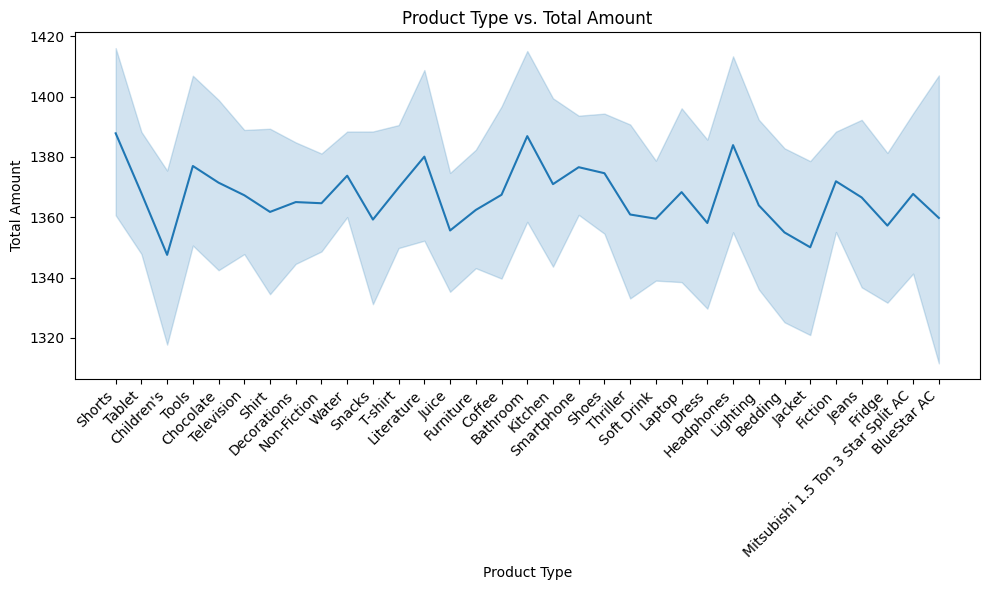

In [9]:
# Relationship between Age Group and Total_Amount

# Define age group bins and labels
age_bins = [18, 25, 35, 45, 55, 100]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55+']

# Create a new column 'Age_Group' based on age bins
df_cleaned['Age_Group'] = pd.cut(df_cleaned['Age'], bins=age_bins, labels=age_labels)

# Create the line plot with age groups
plt.figure(figsize=(8, 6))
sns.barplot(data=df_cleaned, x='Age_Group', y='Total_Amount')
plt.title('Age Group vs. Total Amount')
plt.xlabel('Age Group')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

# Relationship between Gender and Total_Amount
plt.figure(figsize=(8, 6))
sns.barplot(data=df_cleaned, x='Gender', y='Total_Amount')
plt.title('Gender vs. Total Amount')
plt.xlabel('Gender')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

# Relationship between Income and Total_Amount
plt.figure(figsize=(8, 6))
sns.barplot(data=df_cleaned, x='Income', y='Total_Amount')
plt.title('Income vs. Total Amount')
plt.xlabel('Income')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

# Relationship between Customer_Segment and Total_Amount
plt.figure(figsize=(8, 6))
sns.barplot(data=df_cleaned, x='Customer_Segment', y='Total_Amount')
plt.title('Customer Segment vs. Total Amount')
plt.xlabel('Customer Segment')
plt.ylabel('Total Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Relationship between Total_Purchases and Total_Amount
plt.figure(figsize=(8, 6))
sns.lineplot(data=df_cleaned, x='Total_Purchases', y='Total_Amount')
plt.title('Total Purchases vs. Total Amount')
plt.xlabel('Total Purchases')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

# Relationship between Product_Category and Total_Amount
plt.figure(figsize=(8, 6))
sns.lineplot(data=df_cleaned, x='Product_Category', y='Total_Amount')
plt.title('Product Category vs. Total Amount')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Relationship between Product_Brand and Total_Amount
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_cleaned, x='Product_Brand', y='Total_Amount')
plt.title('Product Brand vs. Total Amount')
plt.xlabel('Product Brand')
plt.ylabel('Total Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Relationship between Product_Type and Total_Amount
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_cleaned, x='Product_Type', y='Total_Amount')
plt.title('Product Type vs. Total Amount')
plt.xlabel('Product Type')
plt.ylabel('Total Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


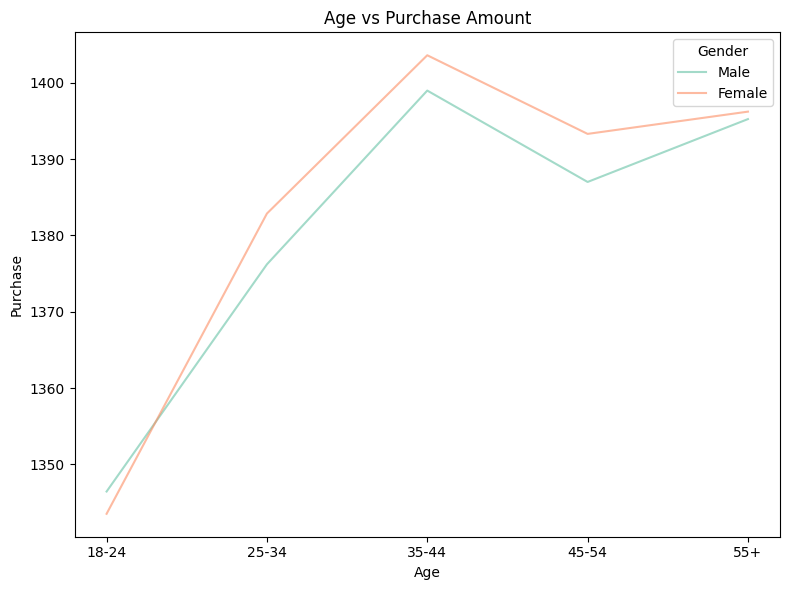

<ipython-input-10-12ad20e52a3b>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cleaned, x='Customer_Segment', y='Total_Amount', palette='Set2')


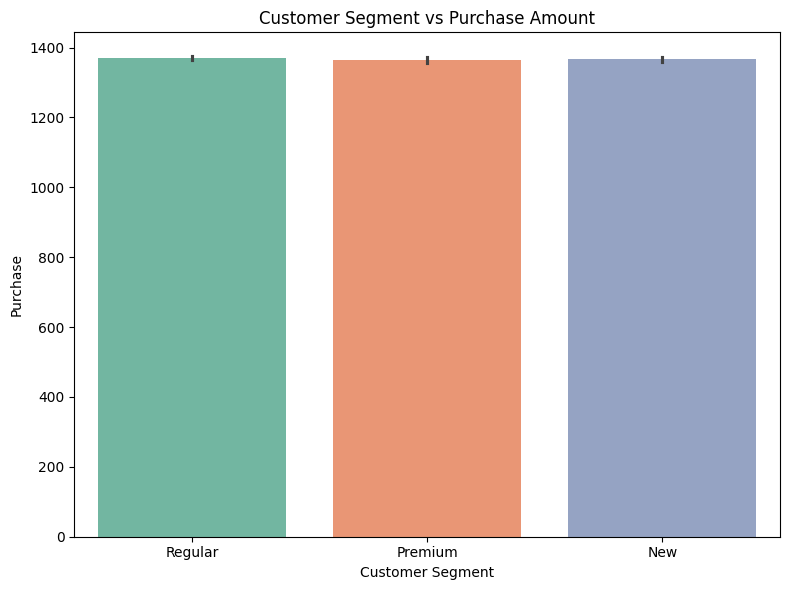

In [10]:

# Relationship between Age and Purchase by Gender
plt.figure(figsize=(8, 6))
sns.lineplot(data=df_cleaned, x='Age_Group', y='Total_Amount', hue='Gender', palette='Set2', alpha=0.6, errorbar=None)
plt.title("Age vs Purchase Amount")
plt.xlabel("Age")
plt.ylabel("Purchase")
plt.tight_layout()
plt.show()

# Boxplot: Customer Segment vs Purchase
plt.figure(figsize=(8, 6))
sns.barplot(data=df_cleaned, x='Customer_Segment', y='Total_Amount', palette='Set2')
plt.title("Customer Segment vs Purchase Amount")
plt.xlabel("Customer Segment")
plt.ylabel("Purchase")
plt.tight_layout()
plt.show()


<ipython-input-11-49f2618d31cd>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])


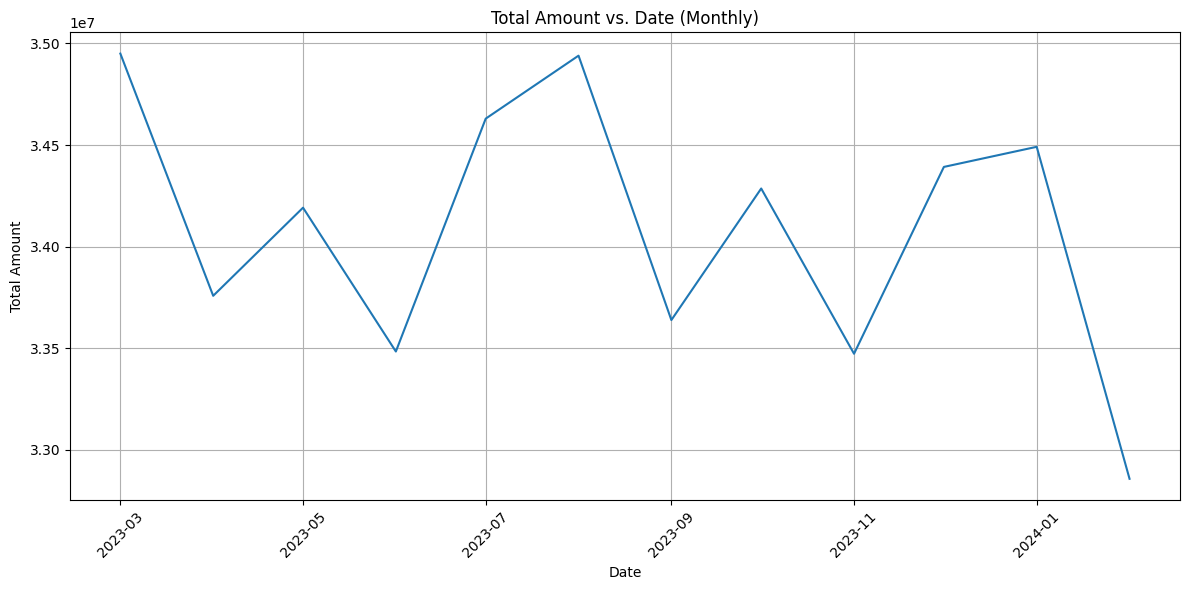

In [11]:

df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])

# Group by month and sum the 'Total_Amount'
monthly_sales = df_cleaned.groupby(df_cleaned['Date'].dt.to_period('M'))['Total_Amount'].sum()

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index.to_timestamp(), monthly_sales.values)
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.title('Total Amount vs. Date (Monthly)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<ipython-input-12-445f43fa770a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[col] = df_cleaned[col].astype('category').cat.codes
<ipython-input-12-445f43fa770a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[col] = df_cleaned[col].astype('category').cat.codes
<ipython-input-12-445f43fa770a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: ht

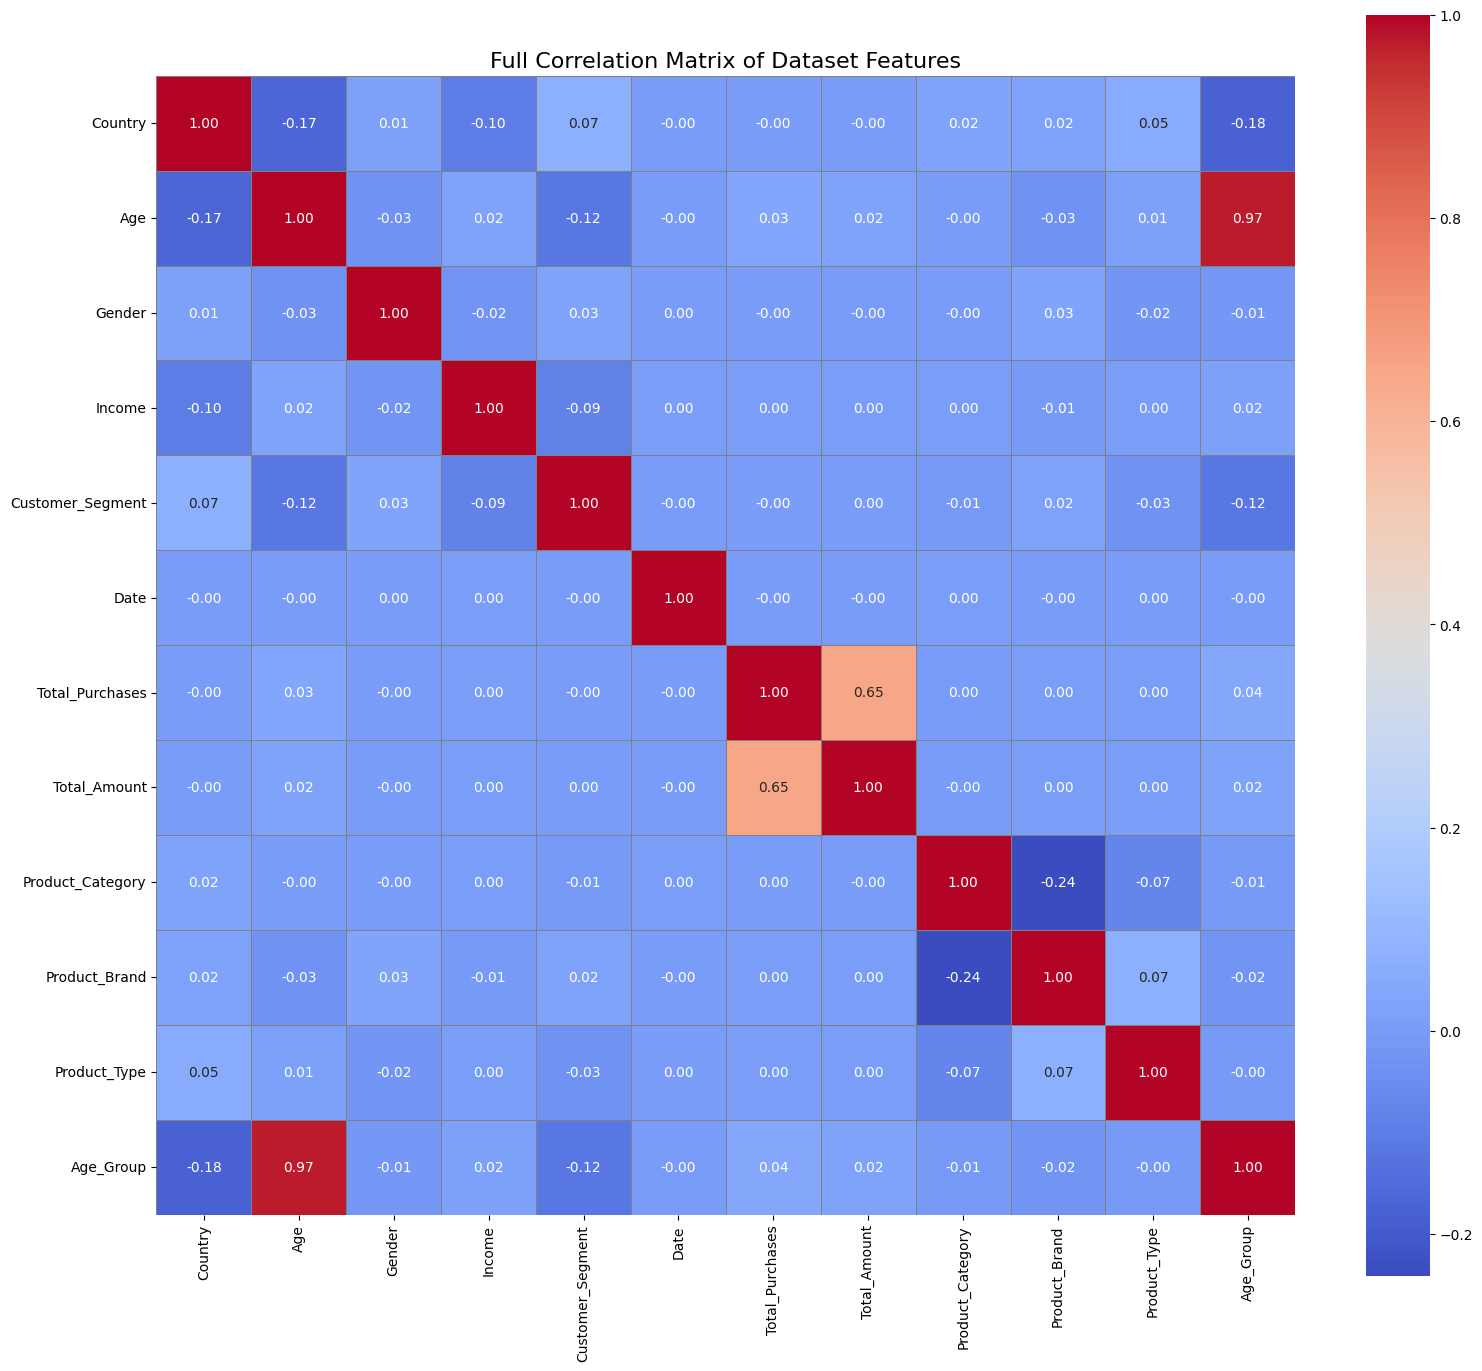

In [12]:
# Encode all categorical variables numerically
for col in df_cleaned.select_dtypes(include=['object', 'category']).columns:
    df_cleaned[col] = df_cleaned[col].astype('category').cat.codes

# Compute correlation matrix
corr_matrix = df_cleaned.corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5, linecolor='grey')
plt.title("Full Correlation Matrix of Dataset Features", fontsize=16)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Model Training

<ipython-input-29-4684db1ced7b>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Gender'] = df_cleaned['Gender'].map({'M': 1, 'F': 0})
<ipython-input-29-4684db1ced7b>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Income'] = df_cleaned['Income'].map({'Low': 0, 'Medium': 1, 'High': 2})
<ipython-input-29-4684db1ced7b>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cavea

Random Forest - MSE: 918157.83, MAE: 708.48, MAPE: 138.72%, R2 Score: 0.28
XGBoost - MSE: 743529.22, MAE: 656.51, MAPE: 135.04%, R2 Score: 0.42

Model Performance Comparison:
            Model            MSE         MAE        MAPE  R2 Score
0  Random Forest  918157.827620  708.482755  138.721217  0.278025
1        XGBoost  743529.220813  656.514680  135.037206  0.415341


<ipython-input-29-4684db1ced7b>:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2 Score", palette="Blues_r")


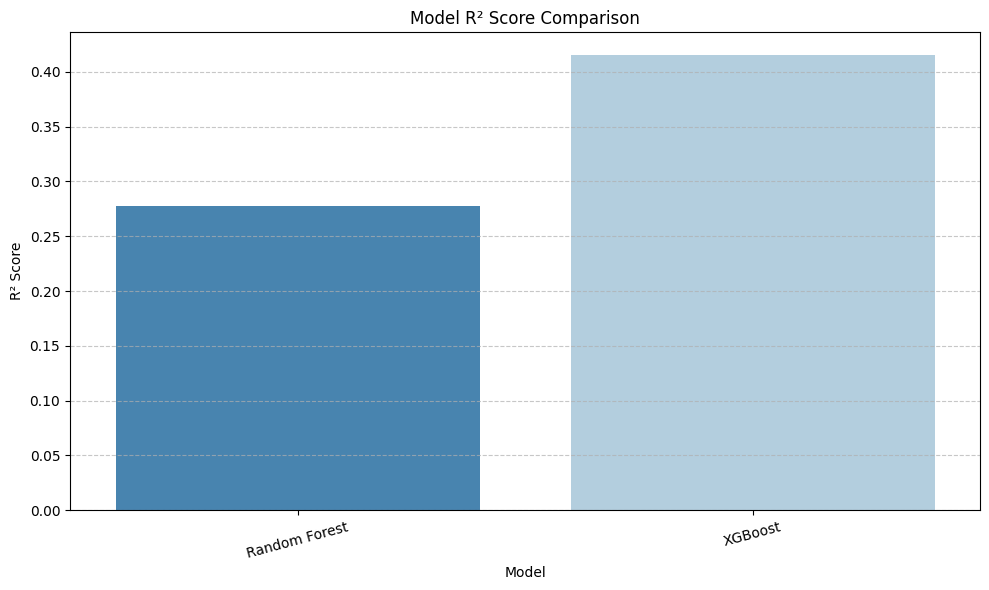

<ipython-input-29-4684db1ced7b>:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="MAPE", palette="Reds_r")


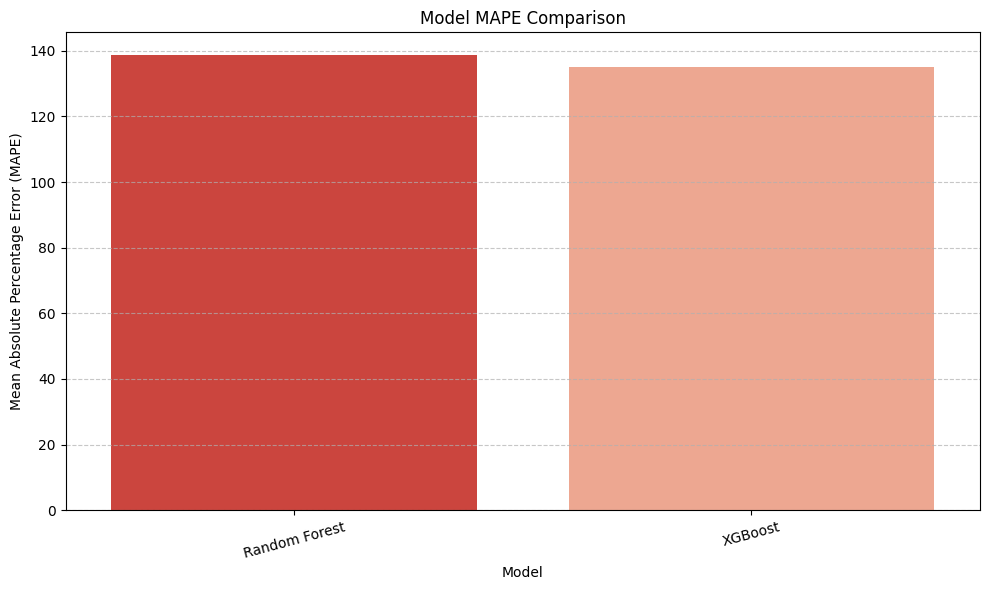

In [29]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Encode categorical variables
df_cleaned['Gender'] = df_cleaned['Gender'].map({'M': 1, 'F': 0})
df_cleaned['Income'] = df_cleaned['Income'].map({'Low': 0, 'Medium': 1, 'High': 2})
df_cleaned['Customer_Segment'] = df_cleaned['Customer_Segment'].map({'New': 0, 'Regular': 1, 'Premium': 2})
df_cleaned['Product_Category'] = df_cleaned['Product_Category'].astype('category').cat.codes

# Extract numerical features from the Date column
df_cleaned['Year'] = df_cleaned['Date'].dt.year
df_cleaned['Month'] = df_cleaned['Date'].dt.month
df_cleaned['Day'] = df_cleaned['Date'].dt.day

# Prepare features and target
features = ['Age', 'Gender', 'Income', 'Customer_Segment',
            'Total_Purchases', 'Product_Category', 'Year', 'Month', 'Day']

X = df_cleaned[features]
y = df_cleaned['Total_Amount']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models (no GridSearch, default parameters)
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42),
}

# Train and evaluate models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)
    results.append((name, mse, mae, mape, r2))
    print(f"{name} - MSE: {mse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%, R2 Score: {r2:.2f}")

results_df = pd.DataFrame(results, columns=["Model", "MSE", "MAE", "MAPE", "R2 Score"])
print("\nModel Performance Comparison:\n", results_df)

# Step 9: Visualise results
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="R2 Score", palette="Blues_r")
plt.title("Model R² Score Comparison")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="MAPE", palette="Reds_r")
plt.title("Model MAPE Comparison")
plt.ylabel("Mean Absolute Percentage Error (MAPE)")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


Random Forest - MSE: 9976771309.17, MAE: 75329.31, MAPE: 17.39%, R2 Score: 0.75
XGBoost - MSE: 9306216765.10, MAE: 72501.51, MAPE: 17.01%, R2 Score: 0.76
MLP Regressor - MSE: 7369571246.93, MAE: 53731.70, MAPE: 13.36%, R2 Score: 0.81
Gradient Boosting - MSE: 9649704405.37, MAE: 75739.34, MAPE: 17.60%, R2 Score: 0.76
SVM - MSE: 41279635131.75, MAE: 161004.06, MAPE: 34.36%, R2 Score: -0.05

Model Performance Comparison:
                Model           MSE            MAE       MAPE  R2 Score
0      Random Forest  9.976771e+09   75329.305431  17.391809  0.747399
1            XGBoost  9.306217e+09   72501.508372  17.007348  0.764377
2      MLP Regressor  7.369571e+09   53731.701314  13.363366  0.813411
3  Gradient Boosting  9.649704e+09   75739.336529  17.600719  0.755680
4                SVM  4.127964e+10  161004.061563  34.359795 -0.045154


<ipython-input-30-a5ee76dc864f>:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2 Score", palette="Blues_r")


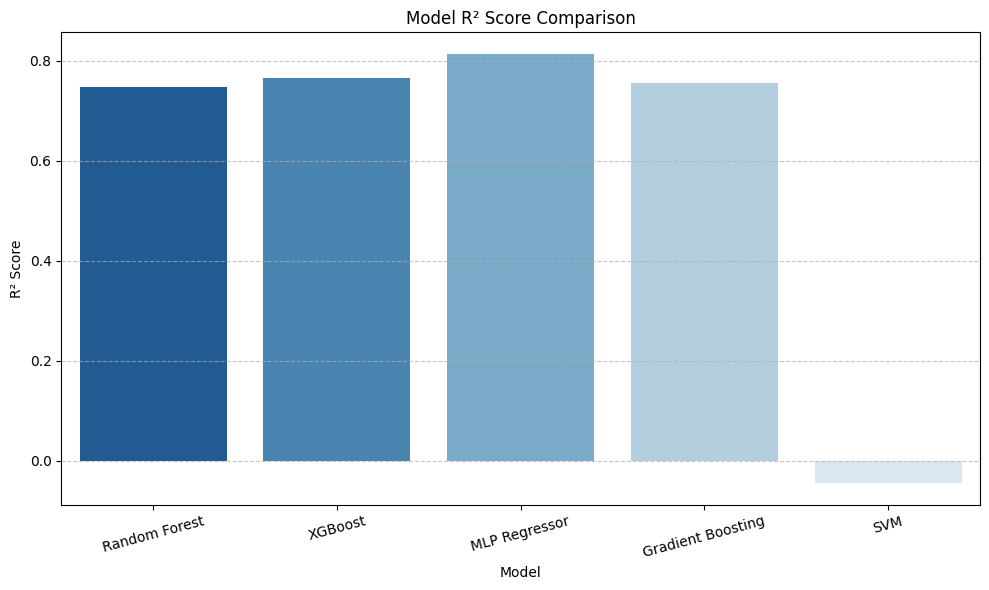

<ipython-input-30-a5ee76dc864f>:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="MAPE", palette="Reds_r")


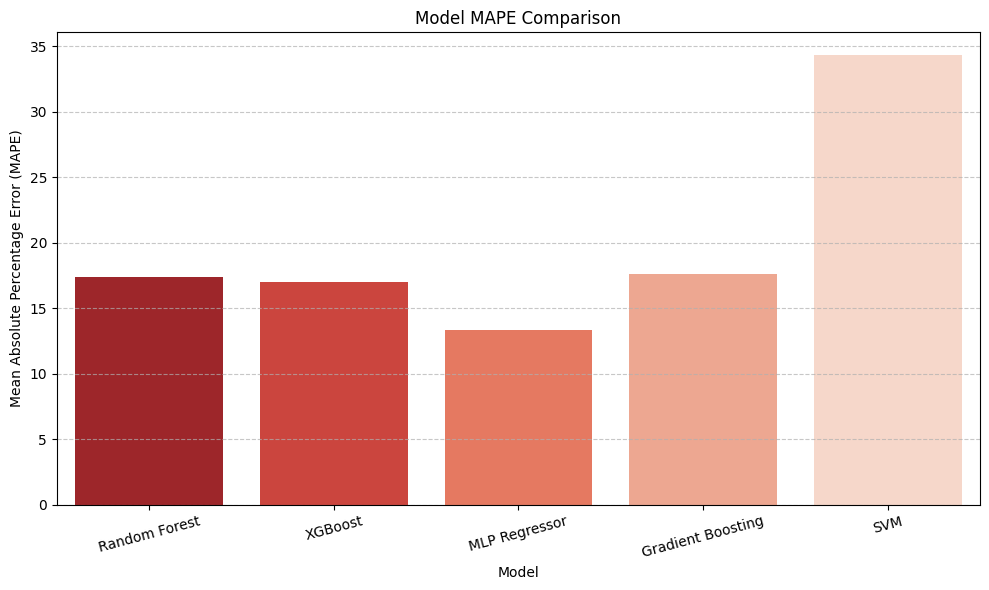

In [30]:

# Import libraries

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

# Step 1: Load dataset
df = pd.read_csv("new_retail_data.csv")

# Step 2: Preprocessing
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Week'] = df['Date'].dt.isocalendar().week
df['Year'] = df['Date'].dt.year

df['Age'] = pd.to_numeric(df['Age'], errors='coerce').fillna(df['Age'].median())
df['Income'] = df['Income'].fillna(df['Income'].mode()[0])
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Total_Amount'] = df['Total_Amount'].fillna(df['Total_Amount'].median())

# Step 3: Aggregate weekly sales
df_weekly = df.groupby(['Year', 'Week', 'Product_Category', 'Customer_Segment'])['Total_Amount'].sum().reset_index()

# Step 4: Aggregate demographics
age_agg = df.groupby(['Year', 'Week', 'Product_Category', 'Customer_Segment'])['Age'].mean().reset_index()
income_agg = df.groupby(['Year', 'Week', 'Product_Category', 'Customer_Segment'])['Income'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown').reset_index()
gender_agg = df.groupby(['Year', 'Week', 'Product_Category', 'Customer_Segment'])['Gender'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown').reset_index()

# Merge aggregated data
df_weekly = df_weekly.merge(age_agg, on=['Year', 'Week', 'Product_Category', 'Customer_Segment'], how='left')
df_weekly = df_weekly.merge(income_agg, on=['Year', 'Week', 'Product_Category', 'Customer_Segment'], how='left')
df_weekly = df_weekly.merge(gender_agg, on=['Year', 'Week', 'Product_Category', 'Customer_Segment'], how='left')

# Encode categorical variables
df_weekly['Product_Category'] = df_weekly['Product_Category'].astype('category').cat.codes
df_weekly['Customer_Segment'] = df_weekly['Customer_Segment'].astype('category').cat.codes
df_weekly['Income'] = df_weekly['Income'].astype('category').cat.codes
df_weekly['Gender'] = df_weekly['Gender'].astype('category').cat.codes

# Step 5: Create lag features
df_weekly['Sales_Lag_1'] = df_weekly.groupby(['Product_Category', 'Customer_Segment'])['Total_Amount'].shift(1)
df_weekly['Sales_Lag_2'] = df_weekly.groupby(['Product_Category', 'Customer_Segment'])['Total_Amount'].shift(2)

df_weekly.fillna(df_weekly['Total_Amount'].median(), inplace=True)

# Step 6: Prepare features and target
features = ['Year', 'Week', 'Product_Category', 'Customer_Segment', 'Age', 'Income', 'Gender', 'Sales_Lag_1', 'Sales_Lag_2']
X = df_weekly[features]
y = df_weekly['Total_Amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Step 7: Define models (no GridSearch, default parameters)
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42),
    "MLP Regressor": MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "SVM": SVR(C=1.0, kernel='rbf')

}

# Step 8: Train and evaluate models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)
    results.append((name, mse, mae, mape, r2))
    print(f"{name} - MSE: {mse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%, R2 Score: {r2:.2f}")

results_df = pd.DataFrame(results, columns=["Model", "MSE", "MAE", "MAPE", "R2 Score"])
print("\nModel Performance Comparison:\n", results_df)

# Step 9: Visualise results
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="R2 Score", palette="Blues_r")
plt.title("Model R² Score Comparison")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="MAPE", palette="Reds_r")
plt.title("Model MAPE Comparison")
plt.ylabel("Mean Absolute Percentage Error (MAPE)")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Stacking

In [31]:
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Base models
base_models = [
    ("rf", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("xgb", XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)),
    ("svr", SVR(C=1.0, kernel='rbf')),
    ("mlp", MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)),
    ("gb", GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
]

# Meta-model: RandomForestRegressor
meta_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Stacking model
stacking_model = StackingRegressor(estimators=base_models, final_estimator=meta_model)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the stacking model
stacking_model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = stacking_model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Stacking Model - MSE: {mse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%, R² Score: {r2:.2f}")

Stacking Model - MSE: 3487789886.81, MAE: 39108.49, MAPE: 7.59%, R² Score: 0.91


## Feature importance


XGBoost Model Feature Importance:
            Feature  Importance
3  Customer_Segment    0.898098
7       Sales_Lag_1    0.057872
8       Sales_Lag_2    0.021355
4               Age    0.010860
1              Week    0.006558
2  Product_Category    0.005257
0              Year    0.000000
6            Gender    0.000000
5            Income    0.000000


<ipython-input-32-cee2b0017a1b>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


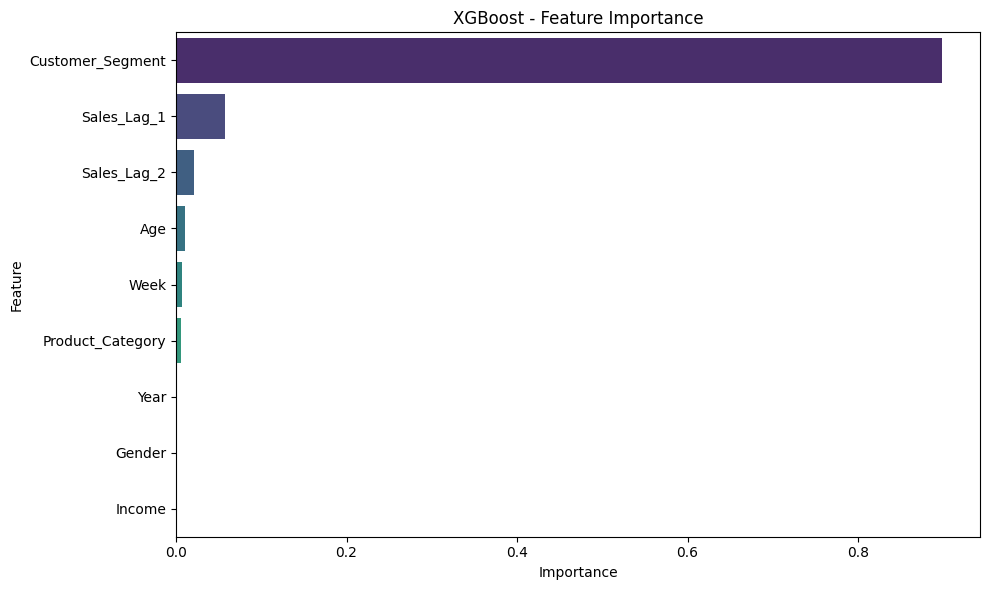

In [32]:
tree_model = models['XGBoost']

# Get feature importance from XGBoost
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display the feature importance
print("\nXGBoost Model Feature Importance:")
print(feature_importance)

# Plotting the feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('XGBoost - Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


<ipython-input-34-8e6c7f3543fc>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


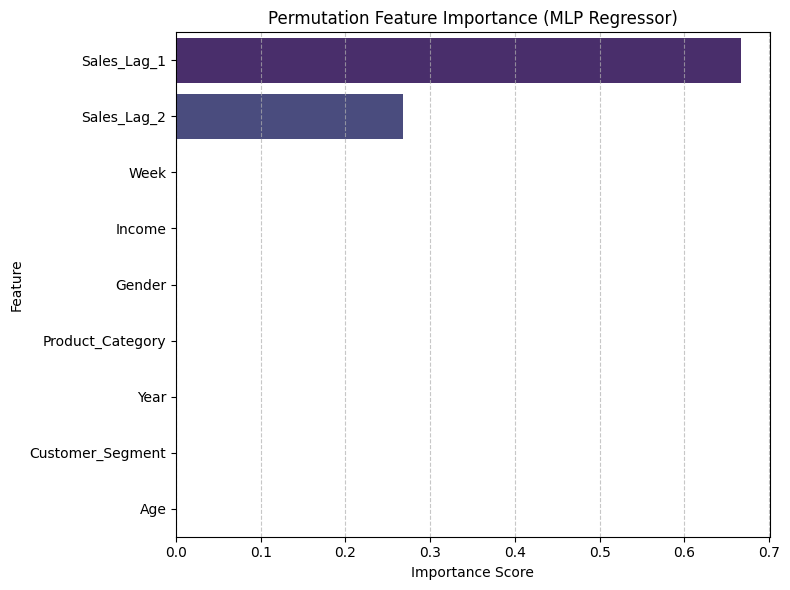


Permutation Importance Results:

            Feature    Importance
7       Sales_Lag_1  6.671722e-01
8       Sales_Lag_2  2.679153e-01
1              Week  1.368281e-07
5            Income  3.550557e-08
6            Gender  0.000000e+00
2  Product_Category -3.777929e-08
0              Year -4.521908e-08
3  Customer_Segment -4.724919e-08
4               Age -3.456670e-07


In [34]:
from sklearn.inspection import permutation_importance
best_model_name = results_df.loc[results_df["MAPE"].idxmin(), "Model"]
best_model = models[best_model_name]

# Permutation Importance
perm_importance = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, scoring='r2')

# Visualise importance
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': perm_importance.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Permutation Feature Importance (MLP Regressor)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display numeric importance
print("\nPermutation Importance Results:\n")
print(importance_df)

## Forecast visual (Actual vs Predicted)


Best Model Selected: MLP Regressor


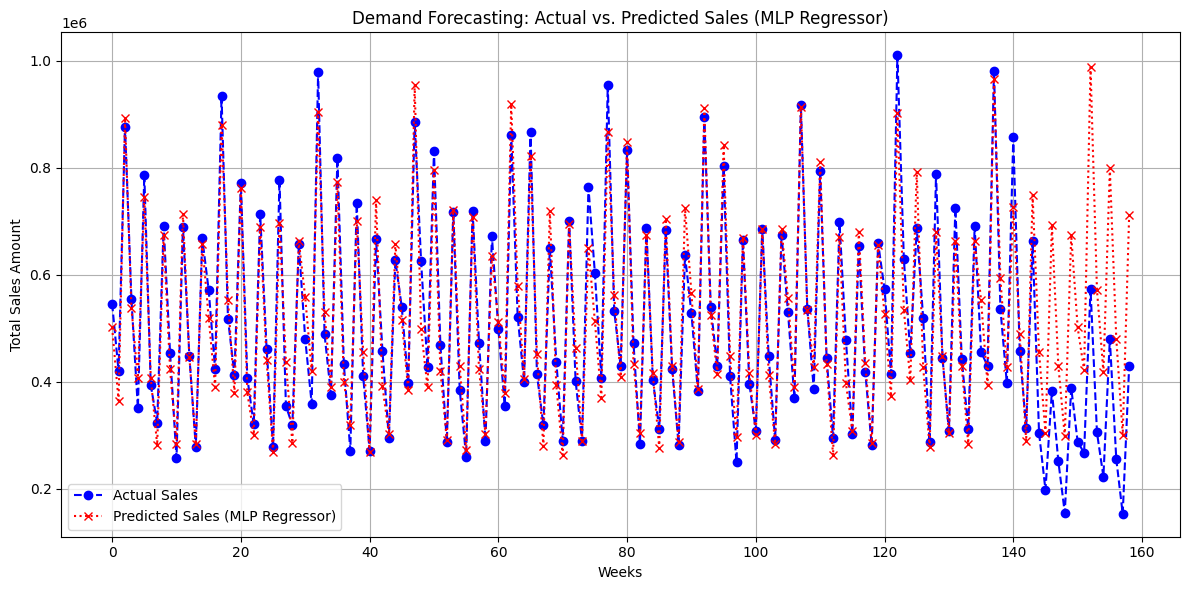

In [ ]:
# Forecasting visualisation for best model
best_model_name = results_df.loc[results_df["MAPE"].idxmin(), "Model"]
best_model = models[best_model_name]

print(f"\nBest Model Selected: {best_model_name}")

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual Sales", marker='o', linestyle='dashed', color='blue')
plt.plot(y_pred_best, label=f"Predicted Sales ({best_model_name})", marker='x', linestyle='dotted', color='red')
plt.xlabel("Weeks")
plt.ylabel("Total Sales Amount")
plt.title(f"Demand Forecasting: Actual vs. Predicted Sales ({best_model_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

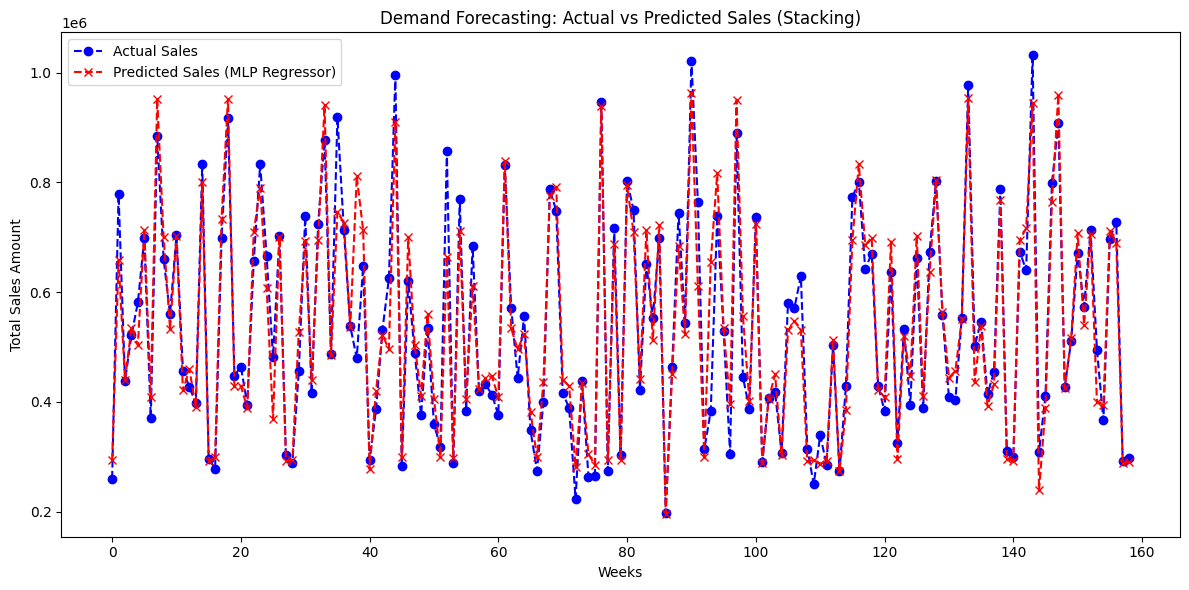

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt

# Create the scatter plot for Actual vs Predicted
plt.figure(figsize=(12, 6))
# Plotting Actual Sales (blue dots)
plt.plot(range(len(y_test)), y_test, 'bo', label='Actual Sales', linestyle='dashed')

# Plotting Predicted Sales (red crosses)
plt.plot(range(len(y_pred)), y_pred, 'rx', label='Predicted Sales (MLP Regressor)', linestyle='dashed')

# Add title and labels
plt.title('Demand Forecasting: Actual vs Predicted Sales (Stacking)')
plt.xlabel('Weeks')
plt.ylabel('Total Sales Amount')

# Add legend
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()


## XAI

In [35]:
# Ensure all categorical and object features are converted to numerical
X_train_numeric = X_train.copy()
X_test_numeric = X_test.copy()

# Convert categorical columns to numeric codes (if necessary)
for col in X_train_numeric.select_dtypes(include=['object', 'category']).columns:
    X_train_numeric[col] = X_train_numeric[col].astype('category').cat.codes
    X_test_numeric[col] = X_test_numeric[col].astype('category').cat.codes

# Ensure all data is numeric
X_train_numeric = X_train_numeric.apply(pd.to_numeric, errors='coerce')
X_test_numeric = X_test_numeric.apply(pd.to_numeric, errors='coerce')


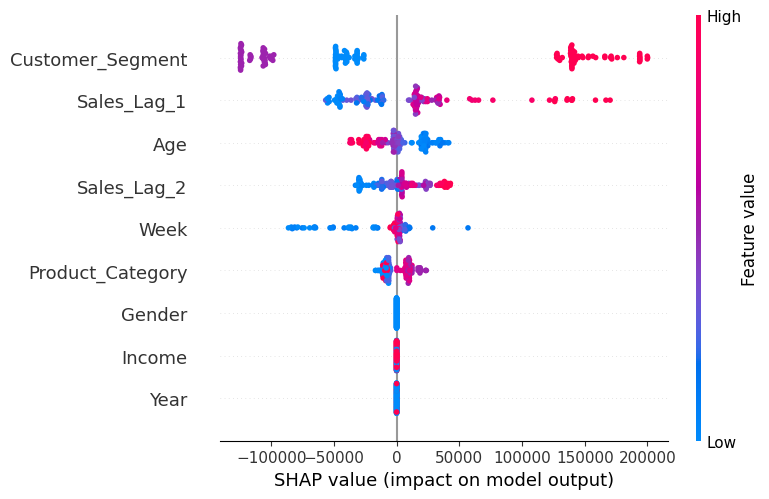

In [38]:
import shap


xgboost_model = models['XGBoost']

# Ensure X_test_numeric has the same columns as the training data
X_test_numeric = X_test_numeric[X_train.columns]

# Initialize SHAP Explainer for XGBoost
explainer = shap.TreeExplainer(xgboost_model)

# Compute SHAP values for the XGBoost model
shap_values = explainer(X_test_numeric)

# SHAP Summary Plot (Feature Importance)
shap.summary_plot(shap_values, X_test_numeric)
